# Tutorial TensorFlow — Classificação de Texto
Reprodução do tutorial oficial *Text classification* (https://www.tensorflow.org/tutorials/keras/text_classification).

**Objetivo:** ler uma resenha de filme e classificá-la como **positiva** ou **negativa** (análise de sentimento). É uma classificação **binária**: a saída é a probabilidade de a resenha ser positiva.

> **Nota sobre os dados:** o notebook original usa o dataset IMDB (50.000 resenhas), baixado de um servidor que este ambiente não acessa. Aqui usamos o corpus **movie_reviews** do NLTK (2.000 resenhas, 1.000 positivas + 1.000 negativas) — a **mesma tarefa e a mesma arquitetura**, com menos dados. Por isso a acurácia fica por volta de **77%** em vez dos ~86% do tutorial original. No Colab, com o IMDB completo, o número sobe.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # silencia logs do TensorFlow
import logging, warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
import numpy as np, re, string
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
import nltk
nltk.download('movie_reviews', quiet=True)
from nltk.corpus import movie_reviews
tf.keras.utils.set_random_seed(42)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 1. Carregar e dividir os dados
Cada arquivo é uma resenha; o rótulo é 1 (positiva) ou 0 (negativa). Embaralhamos e separamos em treino / validação / teste.

In [2]:
texts  = [movie_reviews.raw(f) for f in movie_reviews.fileids()]
labels = [1 if f.startswith('pos') else 0 for f in movie_reviews.fileids()]
texts  = np.array(texts, dtype=object); labels = np.array(labels)

rng = np.random.default_rng(42); idx = rng.permutation(len(texts))
texts, labels = texts[idx], labels[idx]

test_t,  test_l  = texts[:400],   labels[:400]
val_t,   val_l   = texts[400:600], labels[400:600]
train_t, train_l = texts[600:],    labels[600:]
print(f'Treino: {len(train_t)} | Validacao: {len(val_t)} | Teste: {len(test_t)}')
print('\nExemplo de resenha (rotulo =', 'POSITIVA' if train_l[0]==1 else 'NEGATIVA', '):')
print(str(train_t[0])[:300], '...')

Treino: 1400 | Validacao: 200 | Teste: 400

Exemplo de resenha (rotulo = POSITIVA ):
let's face it : the $100 million-plus smash that was " goldeneye " was not a good film by any means , and as a bond movie was only marginally better than , say , " a view to a kill " or either of the timothy dalton pictures , by virtue of nice pacing . 
but it did revive the series , and granted the ...


## 2. Criar os datasets do TensorFlow
`tf.data.Dataset` organiza os dados em lotes (*batches*) de 32 exemplos para alimentar a rede.

In [3]:
bs = 32
raw_train = tf.data.Dataset.from_tensor_slices((list(train_t), train_l)).batch(bs)
raw_val   = tf.data.Dataset.from_tensor_slices((list(val_t),   val_l)).batch(bs)
raw_test  = tf.data.Dataset.from_tensor_slices((list(test_t),  test_l)).batch(bs)

## 3. Padronizar e vetorizar o texto
A rede não entende palavras, só números. Então:
1. **Padronizar**: minúsculas, remover HTML e pontuação.
2. **Vetorizar** (`TextVectorization`): trocar cada palavra por um número inteiro (seu índice no vocabulário) e deixar todas as resenhas com o mesmo tamanho (250 palavras).

In [4]:
def custom_standardization(x):
    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, '<br />', ' ')
    return tf.strings.regex_replace(x, '[%s]' % re.escape(string.punctuation), '')

max_features = 10000   # tamanho do vocabulario
seq_length   = 250     # palavras por resenha
vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization, max_tokens=max_features,
    output_mode='int', output_sequence_length=seq_length)

# 'adapt' aprende o vocabulario a partir do texto de treino
vectorize_layer.adapt(raw_train.map(lambda x, y: x))
print('Tamanho do vocabulario aprendido:', len(vectorize_layer.get_vocabulary()))

Tamanho do vocabulario aprendido: 10000


Vendo o que a vetorização faz com uma frase:

In [5]:
exemplo = tf.constant(['this movie was great and the acting was wonderful'])
print('Texto :', exemplo.numpy()[0].decode())
print('Numeros:', vectorize_layer(exemplo).numpy()[0][:12], '...')

Texto : this movie was great and the acting was wonderful
Numeros: [ 14  29  33 126   4   2 205  33 668   0   0   0] ...


In [6]:
def vectorize_text(text, label):
    return vectorize_layer(text), label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train.map(vectorize_text).cache().prefetch(AUTOTUNE)
val_ds   = raw_val.map(vectorize_text).cache().prefetch(AUTOTUNE)
test_ds  = raw_test.map(vectorize_text).cache().prefetch(AUTOTUNE)

## 4. Montar o modelo
- **Embedding**: aprende um vetor para cada palavra (palavras com sentido parecido ficam próximas).
- **GlobalAveragePooling1D**: tira a média dos vetores da resenha → um único vetor que a representa.
- **Dense(1)**: produz a nota final (transformada em probabilidade pela sigmoide).
- **Dropout**: desliga neurônios aleatoriamente no treino para evitar *overfitting* (decorar).

In [7]:
embedding_dim = 16
model = keras.Sequential([
    keras.Input(shape=(seq_length,), dtype='int64'),
    layers.Embedding(max_features + 1, embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1)])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 16)        │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,033 (625.13 KB)

 Trainable params: 160,033 (625.13 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compilar e treinar
- **loss = BinaryCrossentropy**: padrão para classificação de 2 classes.
- **BinaryAccuracy**: % de acertos.

In [8]:
model.compile(loss=losses.BinaryCrossentropy(from_logits=True), optimizer='adam',
              metrics=[keras.metrics.BinaryAccuracy(threshold=0.0)])
history = model.fit(train_ds, validation_data=val_ds, epochs=25, verbose=0)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f'\n>>> RESULTADO NO TESTE: acuracia = {acc:.3f}  |  loss = {loss:.3f}')


>>> RESULTADO NO TESTE: acuracia = 0.767  |  loss = 0.554


## 6. Curvas de treino
Acompanham o aprendizado época a época. Treino e validação subindo/caindo juntos = aprendizado saudável; se a validação piorasse enquanto o treino melhora, seria *overfitting*.

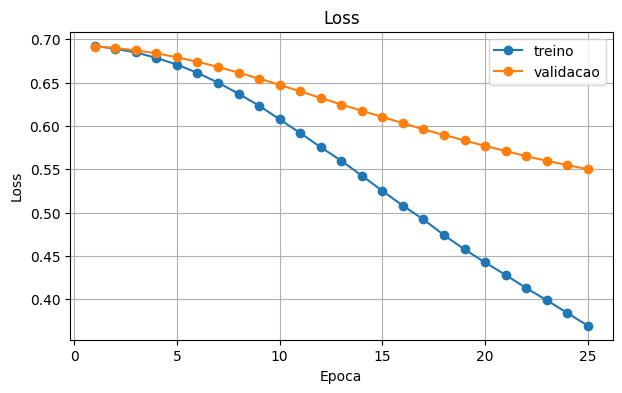

In [9]:
hist = history.history
epochs = range(1, len(hist['loss'])+1)
plt.figure(figsize=(7,4))
plt.plot(epochs, hist['loss'], 'o-', label='treino')
plt.plot(epochs, hist['val_loss'], 'o-', label='validacao')
plt.title('Loss'); plt.xlabel('Epoca'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()

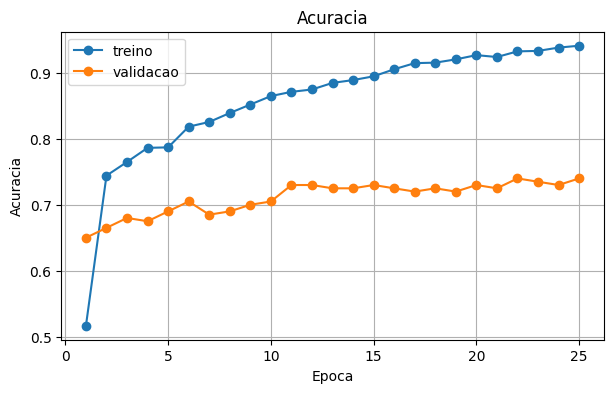

In [10]:
plt.figure(figsize=(7,4))
plt.plot(epochs, hist['binary_accuracy'], 'o-', label='treino')
plt.plot(epochs, hist['val_binary_accuracy'], 'o-', label='validacao')
plt.title('Acuracia'); plt.xlabel('Epoca'); plt.ylabel('Acuracia'); plt.legend(); plt.grid(True); plt.show()

## 7. Modelo final que aceita texto cru
Juntamos a vetorização + o modelo + a sigmoide num só objeto. Agora basta passar o **texto** (sem pré-processar) e ele devolve a probabilidade de ser positiva. Testamos em resenhas reais do conjunto de teste:

In [11]:
export_model = keras.Sequential([vectorize_layer, model, layers.Activation('sigmoid')])
export_model.compile(loss=losses.BinaryCrossentropy(from_logits=False),
                     optimizer='adam', metrics=['accuracy'])

amostras = [str(t) for t in test_t[:8]]
probs = export_model.predict(tf.constant(amostras), verbose=0).flatten()
print('prob  previsto  real   | inicio da resenha')
print('-'*70)
for p, real, t in zip(probs, test_l[:8], test_t[:8]):
    prev = 'POS' if p > 0.5 else 'NEG'
    verd = 'POS' if real == 1 else 'NEG'
    marca = 'ok' if prev == verd else 'X'
    print(f'{p:.2f}   {prev}      {verd}  {marca} | {str(t)[:40]}')

prob  previsto  real   | inicio da resenha
----------------------------------------------------------------------
0.52   POS      POS  ok | what surprises me most about the long-aw
0.30   NEG      NEG  ok | in the series of the erotic thrillers th
0.33   NEG      POS  X | the happy bastard's quick movie review 

0.60   POS      NEG  X | in 1970s , many european intellectuals ,
0.55   POS      NEG  X | synopsis : a man whose lover , paris , w
0.55   POS      NEG  X | there are some pretty impressive stars i
0.28   NEG      NEG  ok | it seemed like the perfect concept . 
wh
0.73   POS      NEG  X | i have never been a " star trek " fan , 


### Conclusão
A rede aprendeu, só a partir dos exemplos, a associar certas palavras a resenhas positivas ou negativas, acertando ~77% das resenhas que nunca tinha visto. A estrutura **Embedding → pooling → Dense** é a base de muitos modelos de processamento de linguagem.

Diferença para a regressão: aqui a saída passa por uma **sigmoide** (probabilidade 0–1) e a loss é *BinaryCrossentropy*; lá a saída era um número direto.